In [1]:
!pip install easyocr
!pip install imutils

   ---------------------------------------- 0.0/2.9 MB ? eta -:--:--
   ------- -------------------------------- 0.5/2.9 MB 3.5 MB/s eta 0:00:01
   ------------------ --------------------- 1.3/2.9 MB 3.3 MB/s eta 0:00:01
   --------------------- ------------------ 1.6/2.9 MB 2.7 MB/s eta 0:00:01
   ------------------------- -------------- 1.8/2.9 MB 2.6 MB/s eta 0:00:01
   ------------------------- -------------- 1.8/2.9 MB 2.6 MB/s eta 0:00:01
   ----------------------------- ---------- 2.1/2.9 MB 1.9 MB/s eta 0:00:01
   -------------------------------- ------- 2.4/2.9 MB 1.7 MB/s eta 0:00:01
   ------------------------------------ --- 2.6/2.9 MB 1.5 MB/s eta 0:00:01
   ---------------------------------------- 2.9/2.9 MB 1.6 MB/s  0:00:01
   ---------------------------------------- 0.0/38.9 MB ? eta -:--:--
    --------------------------------------- 0.8/38.9 MB 4.9 MB/s eta 0:00:08
   - -------------------------------------- 1.8/38.9 MB 4.5 MB/s eta 0:00:09
   -- --------------------

  You can safely remove it manually.
  You can safely remove it manually.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
numba 0.61.0 requires numpy<2.2,>=1.24, but you have numpy 2.2.6 which is incompatible.


  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
  Created wheel for imutils: filename=imutils-0.5.4-py3-none-any.whl size=25890 sha256=914270121dec66228415a4e1e2d3e9b9ba67227e0fb06ddf1d368dffedec28ee
  Stored in directory: c:\users\saksh\appdata\local\pip\cache\wheels\69\2c\66\f966db29490794305257ac3abfe71d4f963f5fc75ba0eb8eb7
Successfully built imutils


  DEPRECATION: Building 'imutils' using the legacy setup.py bdist_wheel mechanism, which will be removed in a future version. pip 25.3 will enforce this behaviour change. A possible replacement is to use the standardized build interface by setting the `--use-pep517` option, (possibly combined with `--no-build-isolation`), or adding a `pyproject.toml` file to the source tree of 'imutils'. Discussion can be found at https://github.com/pypa/pip/issues/6334


In [2]:
import cv2
from matplotlib import pyplot as plt
import numpy as np
import imutils
import easyocr

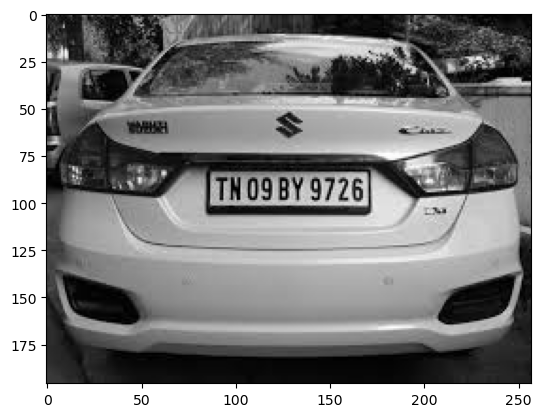

In [86]:
img = cv2.imread("C:\\Users\\saksh\\Downloads\\car7jpeg.jpeg")
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
plt.imshow(cv2.cvtColor(gray, cv2.COLOR_BGR2RGB))

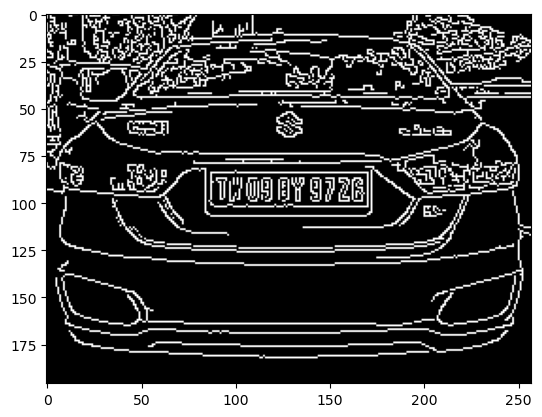

In [87]:
bfilter = cv2.bilateralFilter(gray, 11, 17, 17) #Noice reduction
edged = cv2.Canny(bfilter, 30, 200) #Edge detection
plt.imshow(cv2.cvtColor(edged, cv2.COLOR_BGR2RGB))

In [88]:
keypoints = cv2.findContours(edged.copy(), cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
contours = imutils.grab_contours(keypoints)
contours = sorted(contours, key=cv2.contourArea, reverse=True)[:10]

In [89]:
location = None
for contour in contours:
    approx = cv2.approxPolyDP(contour, 10, True)
    if len(approx) == 4:
        location = approx
        break

In [90]:
location

array([[[ 87,  84]],

       [[ 89, 102]],

       [[170, 102]],

       [[170,  84]]], dtype=int32)

In [91]:
mask = np.zeros(gray.shape, np.uint8)
new_image = cv2.drawContours(mask, [location], 0,255,-1)
new_image = cv2.bitwise_and(img, img, mask=mask)

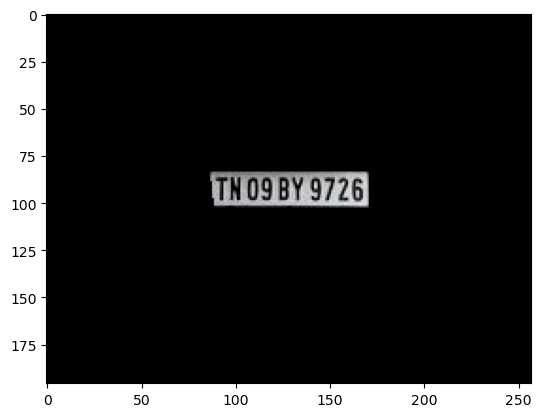

In [92]:
plt.imshow(cv2.cvtColor(new_image, cv2.COLOR_BGR2RGB))

In [93]:
(x,y) = np.where(mask==255)
(x1, y1) = (np.min(x), np.min(y))
(x2, y2) = (np.max(x), np.max(y))
cropped_image = gray[x1:x2+1, y1:y2+1]

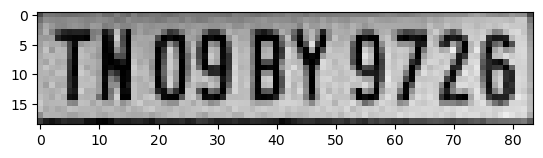

In [94]:
plt.imshow(cv2.cvtColor(cropped_image, cv2.COLOR_BGR2RGB))

In [95]:
reader = easyocr.Reader(['en'])
result = reader.readtext(cropped_image)
result

Neither CUDA nor MPS are available - defaulting to CPU. Note: This module is much faster with a GPU.


[([[0, 0], [84, 0], [84, 19], [0, 19]],
  'IhQg BY 9726',
  np.float64(0.25272621264352524))]

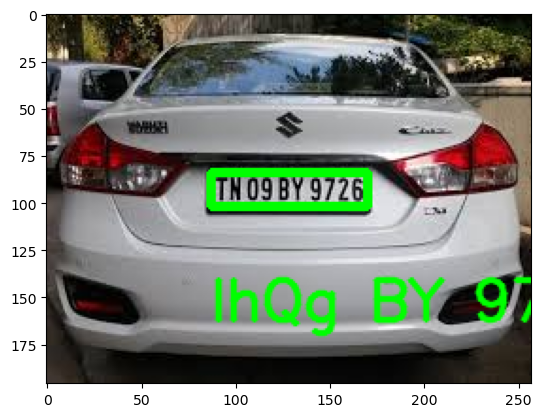

In [96]:
text = result[0][-2]
font = cv2.FONT_HERSHEY_SIMPLEX
res = cv2.putText(img, text=text, org=(approx[0][0][0], approx[1][0][1]+60), fontFace=font, fontScale=1, color=(0,255,0), thickness=2, lineType=cv2.LINE_AA)
res = cv2.rectangle(img,tuple(approx[0][0]), tuple(approx[2][0]),(0,255,0),3)
plt.imshow(cv2.cvtColor(res, cv2.COLOR_BGR2RGB))